<a href="https://colab.research.google.com/github/varunsahu5002/VDUI-ASSIGNMENT---1/blob/assignment-submission/ppt3_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚨 THE 20-MINUTE SPRINT 🚨
### A Data Visualization Fire Drill — Unit 1 Activity (UE24CS342AA9)

---

**08:47 AM.** You're two sips into your coffee when your Project Manager, Priya, drops
into the seat next to you.

> *"Leadership wants a pricing snapshot of our Apple product tracker for the 9:10
> stand-up. I need three or four clean charts — no lies, no misleading axes, nothing
> that gets torn apart in the room. You've got until 9:07. Go."*

It's **9:07 AM**. That's **20 minutes**, starting now.

You have one dataset (`apple_products_pricing_2020_2026.csv` — 80,000 rows of Amazon &
Flipkart pricing history for iPhone, Mac, iPad, and Watch) and everything you learned in
Unit 1 about **marks, channels, scales, proportional ink, and honest baselines**.

Leadership has seen bad charts before. They will notice a truncated bar axis. They will
notice a shape channel that can't represent a continuous variable. **Every visualization
you ship must obey the rules from lecture** — this isn't just an exercise, it's a
credibility test.

---

### 🎯 Mission Rules
1. Work through **Tasks 1–4** below, in order. Each has a suggested time box — keep moving.
2. Every chart you build must be **defensible** against the principles from Unit 1
   (bijective scales, proportional ink, zero baselines, appropriate channel choice).
3. At **Task 5**, do the honest self-audit before you "submit."
4. Finish with the **Reflection** section — that's where the real grade lives.

Ready? Run the setup cell and **start your timer**.


In [6]:
# --- MISSION SETUP: Run this first, then start your 20-minute timer ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Find the uploaded CSV automatically
csv_files = list(Path(".").glob("*.csv"))

print("CSV files found:", csv_files)

if not csv_files:
    raise FileNotFoundError(
        "No CSV file found. Upload the updated Apple pricing CSV to the notebook first."
    )

# Use the Apple pricing CSV
apple_csv = next(
    (f for f in csv_files if "apple" in f.name.lower() and "pricing" in f.name.lower()),
    csv_files[0]
)

df = pd.read_csv(apple_csv, parse_dates=["Date"])

mission_start = time.time()

print("MISSION CLOCK STARTED.")
print(f"Loaded {len(df):,} rows. You have 20 minutes. Go.")
print(f"Using: {apple_csv.name}")

CSV files found: [PosixPath('apple_products_pricing_2020_2026 .csv')]
MISSION CLOCK STARTED.
Loaded 80,000 rows. You have 20 minutes. Go.
Using: apple_products_pricing_2020_2026 .csv


In [ ]:
# Run this cell any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 20 - elapsed_min)
bar = "🟩" * int(remaining) + "⬜" * (20 - int(remaining))
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")
print(bar)
if remaining < 5:
    print("⚠️  Under 5 minutes -- wrap up your current chart and move to Task 5.")


Elapsed: 0.0 min   |   Remaining: 20.0 min
🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜


---
## Task 1 — Know Your Variables *(~3 min)*

Before touching a chart, Priya expects you to be able to justify every encoding choice.
Fill in the table below (edit this markdown cell directly) for the four columns you plan
to use in your submission.

| Column you'll use | Variable type (continuous / discrete quantitative / ordered / unordered qualitative) | Channel you plan to map it to |
|---|---|---|
| *e.g. Current_Price_USD* | *e.g. Continuous quantitative* | *e.g. y-position* |
| | | |
| | | |
| | | |

**Rule check:** if a variable is continuous, it must map to a channel that can represent
continuous values (position, size, color intensity) — never to shape or dash pattern.


---
## Task 2 — The Headline Bar Chart *(~5 min)*

Leadership always looks at the bar chart first. Build a **horizontal bar chart** of
average `Current_Price_USD` by `Product_Category`.

**Non-negotiable:** the baseline must be zero. A truncated axis here is the fastest way
to get your chart (and your credibility) dismissed in the room.

Fill in the `# TODO` lines below.


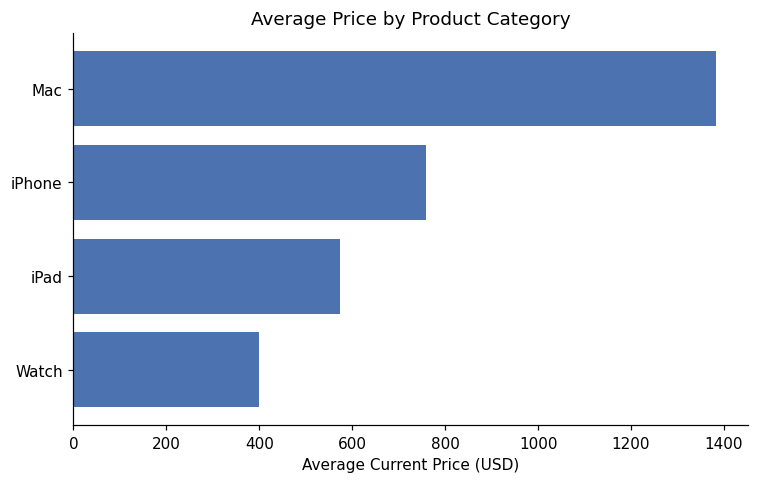

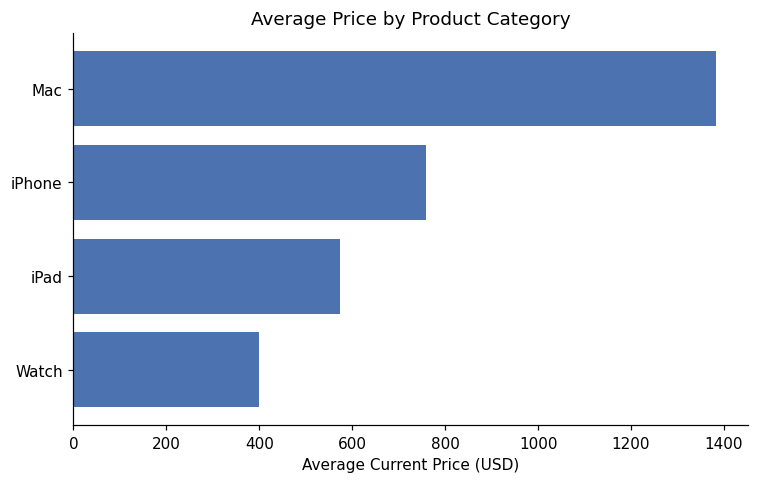

In [7]:
# TODO: compute average Current_Price_USD grouped by Product_Category, sorted ascending
cat_avg = df.groupby("Product_Category")["Current_Price_USD"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4.5))

# TODO: plot a horizontal bar chart (ax.barh) using cat_avg
ax.barh(cat_avg.index, cat_avg.values, color="#4C72B0")

# TODO: enforce the zero-baseline rule -- do NOT delete this line
ax.set_xlim(left=0)

ax.set_xlabel("Average Current Price (USD)")
ax.set_title("Average Price by Product Category")
plt.tight_layout()
plt.show()
cat_avg = df.groupby("Product_Category")["Current_Price_USD"].mean().sort_values()  # TODO: is this the right column/agg?

fig, ax = plt.subplots(figsize=(7, 4.5))

# TODO: plot a horizontal bar chart (ax.barh) using cat_avg
ax.barh(cat_avg.index, cat_avg.values, color="#4C72B0")

# TODO: enforce the zero-baseline rule -- do NOT delete this line
ax.set_xlim(left=0)

ax.set_xlabel("Average Current Price (USD)")
ax.set_title("Average Price by Product Category")
plt.tight_layout()
plt.show()


---
## Task 3 — The Trend Line, Done Right *(~5 min)*

Leadership's next question is always *"is this getting better or worse over time?"*
Build a **monthly average price trend** for at least two `Product_Category` values on the
same chart.

**Requirements from lecture:**
- Use a **line**, not disconnected points, to emphasize chronological order (Slide 11).
- Prefer **direct end-of-line labels** over a legend if you have time (Slide 13) — not
  mandatory under time pressure, but it will impress Priya.
- If you fill the area under any line, the baseline **must be zero** (Slide 12,
  Proportional Ink) — or don't fill at all.


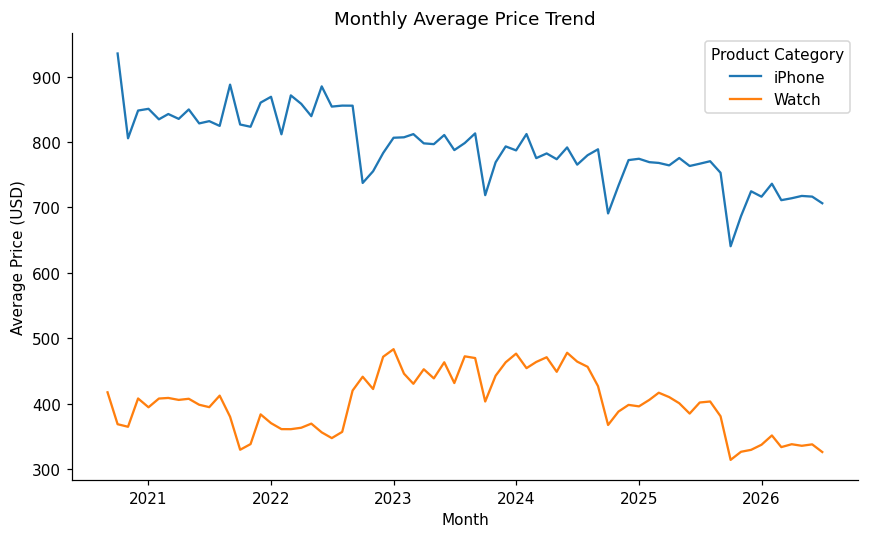

In [8]:
# TODO: pick 2+ categories to compare
categories_to_plot = ["iPhone", "Watch"]

fig, ax = plt.subplots(figsize=(8, 5))

for cat in categories_to_plot:
    # Resample to monthly average price for this category
    monthly = (
        df[df["Product_Category"] == cat]
        .set_index("Date")
        .resample("MS")["Current_Price_USD"]
        .mean()
    )

    ax.plot(monthly.index, monthly.values, linewidth=1.5, label=cat)

ax.legend(title="Product Category")
ax.set_xlabel("Month")
ax.set_ylabel("Average Price (USD)")
ax.set_title("Monthly Average Price Trend")
plt.tight_layout()
plt.show()

---
## Task 4 — The "Wow" Multi-Variable Chart *(~5 min)*

Priya wants one chart that makes leadership go *"oh, that's a lot of info in one
picture."* Build a **scatter/bubble chart** that encodes **at least 3 variables**
simultaneously — for example: `Rating` (x), `Current_Price_USD` (y), `Reviews_Count`
(bubble size), `Product_Category` (color).

**Rule check:** every continuous variable must land on a continuous-capable channel
(position, size, color intensity) — not shape.


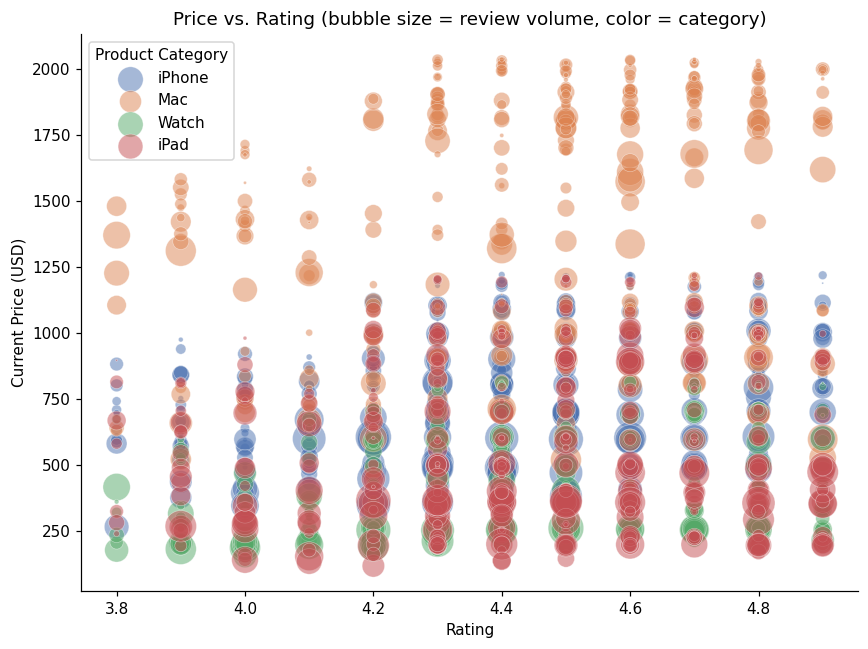

In [9]:
# TODO: build your 3+ variable bubble chart here

sample = df.sample(2000, random_state=1)

cat_color = {
    "iPhone": "#4C72B0",
    "Mac": "#DD8452",
    "Watch": "#55A868",
    "iPad": "#C44E52"
}

fig, ax = plt.subplots(figsize=(8, 6))

for cat, color in cat_color.items():
    d = sample[sample["Product_Category"] == cat]

    ax.scatter(
        d["Rating"],                  # x = Rating
        d["Current_Price_USD"],       # y = Current_Price_USD
        s=d["Reviews_Count"] / 20,    # size = Reviews_Count
        color=color,                  # color = Product_Category
        alpha=0.5,
        edgecolor="white",
        linewidth=0.4,
        label=cat
    )

ax.set_xlabel("Rating")
ax.set_ylabel("Current Price (USD)")
ax.set_title("Price vs. Rating (bubble size = review volume, color = category)")
ax.legend(title="Product Category")
plt.tight_layout()
plt.show()

---
## Task 5 — The Submission Audit *(~2 min)*

The clock is almost out. Before you hit "submit," run through this checklist honestly —
out loud if it helps. Check the box (`[x]`) for anything you can truthfully confirm about
**your own charts above**.

- [ ] Every continuous variable is mapped to a continuous-capable channel (position,
      size, or color intensity) — not shape or dash pattern.
- [ ] Every bar chart's axis starts at zero.
- [ ] Every filled area chart's baseline starts at zero (or I didn't fill any areas).
- [ ] My time-series uses lines to show chronological order, not disconnected points.
- [ ] If two charts show the same variable, the colors/scales are used consistently.
- [ ] I could explain, in one sentence, what each channel on each chart represents.

Run the cell below to log your finish time.


In [ ]:
elapsed_min = (time.time() - mission_start) / 60
print(f"🏁 SUBMITTED at {elapsed_min:0.1f} minutes into the mission.")
if elapsed_min <= 20:
    print("✅ On time. Priya nods and walks it into the stand-up.")
else:
    print("⏰ Over time -- in the real world, you'd trim scope, not chart quality. Note this for your reflection.")


🏁 SUBMITTED at 0.0 minutes into the mission.
✅ On time. Priya nods and walks it into the stand-up.


---
## 🪞 Reflection

Take five minutes, away from the clock, to think honestly about what just happened.
Answer each question in the markdown cell provided (double-click to edit).

**1. Time pressure and technique.** Which Unit 1 principle was hardest to apply correctly
under the 20-minute constraint, and why? Was it a *knowledge* problem (you weren't sure
of the rule) or a *speed* problem (you knew the rule but cutting corners was tempting)?

*Your answer:*

The hardest principle to apply under the 20-minute constraint was choosing the correct visual channel for each variable. I understood the rules, but under time pressure it was easy to focus more on getting the chart working than checking every encoding carefully. So for me it was more of a speed problem than a knowledge problem. I knew that continuous variables should use things like position or size, but I still had to consciously check the choices while building the charts.

---

**2. Spot the near-miss.** Look back at your own charts. Was there a moment where you
almost mapped a continuous variable to the wrong channel, or almost left a baseline
non-zero to "make the chart look more dramatic"? What stopped you (or what didn't)?

*Your answer:*

A near-miss was making sure that the continuous variables in Task 4 were mapped to position and size instead of using shape. Since Product Category was categorical, it was safe to use color for it. I also had to make sure the bar chart in Task 2 started at zero. The assignment explicitly called attention to misleading baselines, which made it easier to catch before submitting.

---

**3. The cost of dishonest ink.** Recall the Principle of Proportional Ink. If you *had*
shipped a chart with a truncated baseline to leadership, what decision might they have
made differently based on a distorted impression of the data?

*Your answer:*

If I had used a truncated baseline in Task 2, the differences between the product categories could have looked much larger than they actually were. Leadership might have assumed that one product category was dramatically more expensive than another and potentially made pricing, inventory, or marketing decisions based on an exaggerated difference. The actual values would not have changed, but the visual impression would have been misleading.


---

**4. Trade-offs under constraint.** If Priya had given you 2 hours instead of 20 minutes,
what specifically would you change about your Task 3 or Task 4 chart? (e.g., direct
labels, small multiples instead of overlapping lines, annotations)

*Your answer:*

With two hours instead of 20 minutes, I would improve Task 3 by using direct end-of-line labels instead of relying on the legend. I would also consider using small multiples if the lines became difficult to compare. For Task 4, I would spend more time adjusting the bubble sizes and possibly adding annotations for interesting patterns or outliers. I would keep the same basic encodings because they follow the principles correctly.


---

**5. Beyond the classroom.** Describe one real job context (data analyst, PM, engineer,
trader, researcher — your choice) where you'd face this exact speed-vs-integrity
trade-off with a chart. What would *you* refuse to compromise on, even under a deadline?

*Your answer:*

 A data analyst working for a company could face the same situation when a manager needs a quick report before a meeting. There may only be a few minutes to turn raw data into a chart, but a misleading chart could lead to a bad business decision. Even under a deadline, I would refuse to compromise on honest scales, accurate baselines, and appropriate visual encodings. I would rather provide a simple and truthful chart than a more impressive-looking chart that gives the wrong impression.

